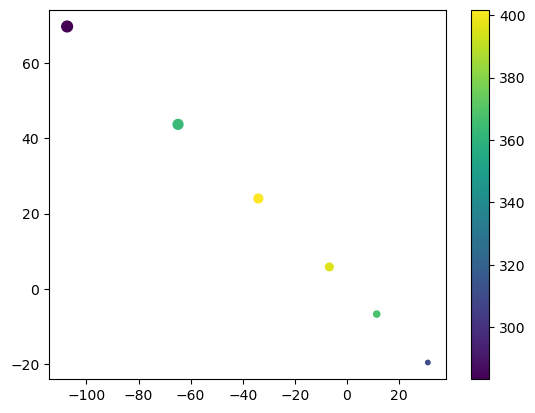

In [7]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from fit_gaussian import statistics_skewness

with open("/home/rydpiservo/servodata/servorecover2/xxdot_scan_when_moving_yydot.pkl","rb") as f:
    dataYoffset = pickle.load(f)

muList = []
sigmaList = []
skewList = []
ZrowList = []
for i in range(-2,4):
    for j in range(len(dataYoffset)):
        if dataYoffset[j][0] == i:
            mu,cov  = dataYoffset[j][1]
            # print(mu)
            muList.append(mu)
            eigval,eigvec = np.linalg.eig(cov)
            sigma = np.sqrt(eigval)
            sigmaList.append(sigma[0])
            Z = dataYoffset[j][4]
            Z_row = np.sum(Z,axis=0)
            ZrowList.append(Z_row)
            X = dataYoffset[j][2]
            X0 = X[0,:]
            skewList.append(statistics_skewness(X0,Z_row))

xList=[mu[0] for mu in muList]
yList=[mu[1] for mu in muList]
plt.scatter(xList,yList,s=np.arange(len(xList))*10+10,c=sigmaList)
plt.colorbar()

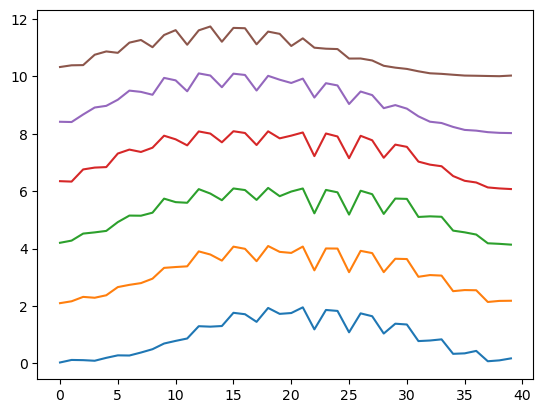

In [9]:
for i,Zrow in enumerate(ZrowList):
    plt.plot(Zrow+i*2)

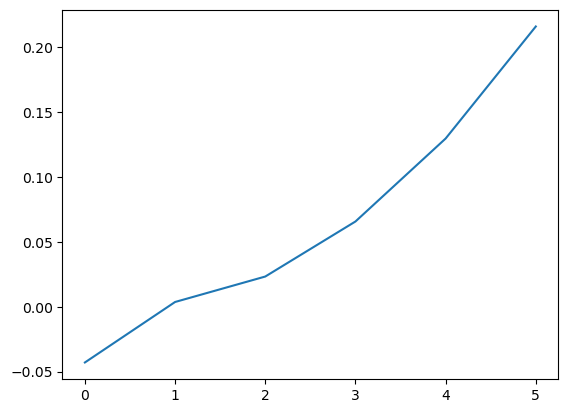

In [12]:
plt.plot(skewList)